# CONVOLUTIONAL NETWORKS

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, GlobalMaxPooling1D, Reshape
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

## Probamos con embbedings contextuales -> Elmo -> Pooling: mean

In [6]:
# cargamos los embeddings generados previamente
X_train = np.load("../data/processed/Elmo/mean/X_train_elmo_mean.npy")
X_test  = np.load("../data/processed/Elmo/mean/X_test_elmo_mean.npy")

# cargamos las etiquetas con el mismo split que usamos al generar los embeddings
df = pd.read_csv('../data/raw/tcga_simple_train.csv')
_, _, y_train, y_test = train_test_split(df['text'], df['t'], test_size=0.2, random_state=42)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Clases:", le.classes_)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Clases: ['T1' 'T2' 'T3' 'T4']
X_train: (4126, 1024), X_test: (1032, 1024)
y_train: (4126,), y_test: (1032,)


c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 1, 256)         │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,732 (1.41 MB)

 Trainable params: 369,732 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3054 - loss: 1.5052 - val_accuracy: 0.3777 - val_loss: 1.4662
Epoch 2/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3315 - loss: 1.4611 - val_accuracy: 0.3220 - val_loss: 1.4442
Epoch 3/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3283 - loss: 1.4446 - val_accuracy: 0.3608 - val_loss: 1.4221
Epoch 4/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3377 - loss: 1.4272 - val_accuracy: 0.3390 - val_loss: 1.4105
Epoch 5/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3499 - loss: 1.4119 - val_accuracy: 0.4140 - val_loss: 1.3907
Epoch 6/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3609 - loss: 1.3970 - val_accuracy: 0.3826 - val_loss: 1.3781
Epoch 7/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3768 - loss: 1.3866 - val_accuracy: 0.4504 - val_loss: 1.3597
Epoch 8/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3867 - loss: 1.3699 - val_accu

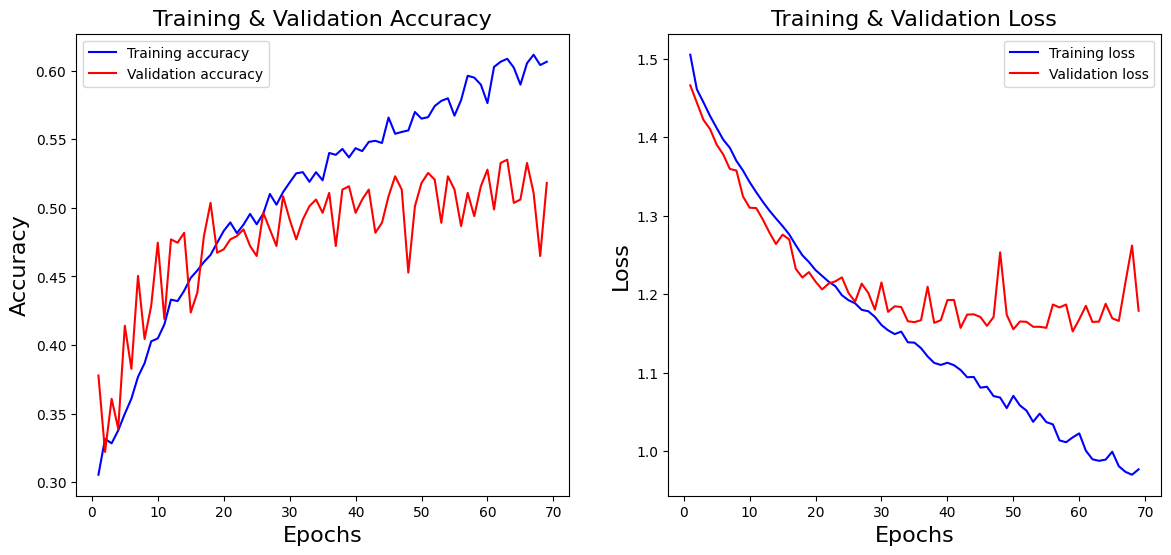

In [7]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

num_clases = len(le.classes_)

from tensorflow.keras.regularizers import l2
from sklearn.metrics import f1_score, classification_report

model = Sequential()
model.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[2])))
model.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_clases, activation='softmax'))

model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

y_pred = model.predict(X_test)
y_pred_clases = np.argmax(y_pred, axis=1)

print(f"F1 Macro:    {f1_score(y_test, y_pred_clases, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_clases, average='weighted'):.4f}")
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))

history_dict    = history.history
loss_values     = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals   = history_dict['accuracy']
val_accuracy    = history_dict['val_accuracy']
epochs          = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(epochs, accuracy_vals, 'b',   label='Training accuracy')
ax[0].plot(epochs, val_accuracy,  'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()

ax[1].plot(epochs, loss_values,     'b',   label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

plt.show()

In [8]:
# ver distribucion de clases
import pandas as pd

df_dist = pd.Series(y_train).value_counts().sort_index()
print("Distribución clases (train):")
for i, count in enumerate(df_dist):
    print(f"  {le.classes_[i]}: {count} muestras")

# ver el f1 por clase del ultimo modelo
y_pred = model.predict(X_test)
y_pred_clases = np.argmax(y_pred, axis=1)
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))

Distribución clases (train):
  T1: 1047 muestras
  T2: 1383 muestras
  T3: 1277 muestras
  T4: 419 muestras
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

               precision    recall  f1-score   support

          T1       0.52      0.62      0.57       255
          T2       0.52      0.48      0.50       369
          T3       0.52      0.57      0.55       306
          T4       0.49      0.24      0.32       102

    accuracy                           0.52      1032
   macro avg       0.51      0.48      0.48      1032
weighted avg       0.52      0.52      0.51      1032



## Probamos con embbedings contextuales -> Elmo -> Pooling: max

In [10]:
# cargamos los embeddings generados previamente
X_train = np.load("../data/processed/Elmo/max/X_train_elmo_max.npy")
X_test  = np.load("../data/processed/Elmo/max/X_test_elmo_max.npy")

# cargamos las etiquetas con el mismo split que usamos al generar los embeddings
df = pd.read_csv('../data/raw/tcga_simple_train.csv')
_, _, y_train, y_test = train_test_split(df['text'], df['t'], test_size=0.2, random_state=42)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Clases:", le.classes_)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Clases: ['T1' 'T2' 'T3' 'T4']
X_train: (4126, 1024), X_test: (1032, 1024)
y_train: (4126,), y_test: (1032,)


c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 1, 256)         │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,732 (1.41 MB)

 Trainable params: 369,732 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2952 - loss: 1.5219 - val_accuracy: 0.3051 - val_loss: 1.4686
Epoch 2/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3181 - loss: 1.4804 - val_accuracy: 0.3269 - val_loss: 1.4565
Epoch 3/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3256 - loss: 1.4617 - val_accuracy: 0.2978 - val_loss: 1.4429
Epoch 4/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3248 - loss: 1.4558 - val_accuracy: 0.3148 - val_loss: 1.4366
Epoch 5/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3313 - loss: 1.4460 - val_accuracy: 0.3269 - val_loss: 1.4281
Epoch 6/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3404 - loss: 1.4367 - val_accuracy: 0.3051 - val_loss: 1.4242
Epoch 7/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3275 - loss: 1.4357 - val_accuracy: 0.3245 - val_loss: 1.4161
Epoch 8/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3299 - loss: 1.4278 - val_accu

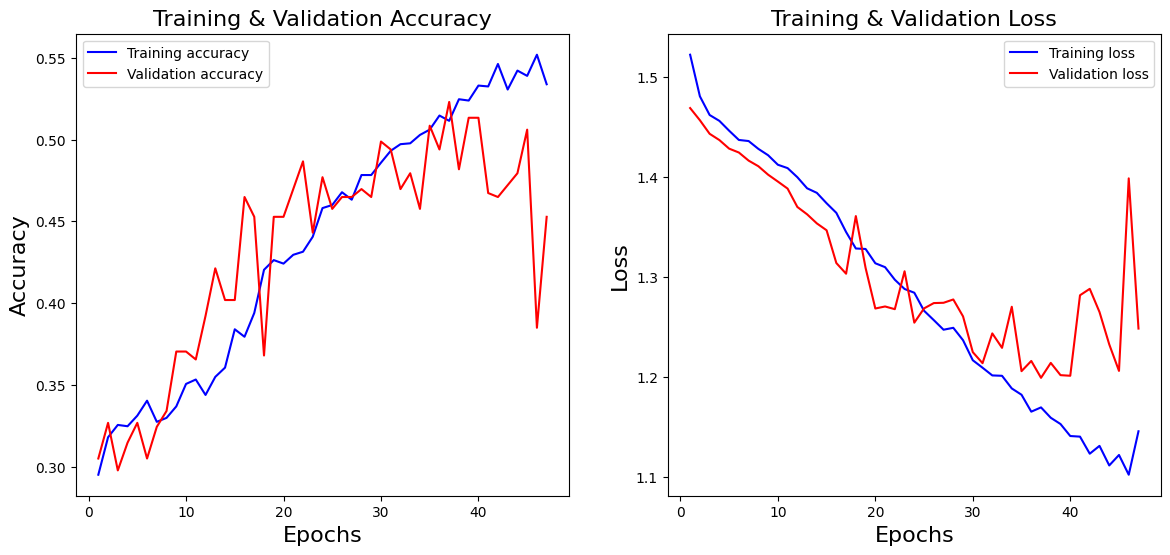

In [11]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

num_clases = len(le.classes_)

from tensorflow.keras.regularizers import l2
from sklearn.metrics import f1_score, classification_report

model = Sequential()
model.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[2])))
model.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_clases, activation='softmax'))

model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

y_pred = model.predict(X_test)
y_pred_clases = np.argmax(y_pred, axis=1)

print(f"F1 Macro:    {f1_score(y_test, y_pred_clases, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_clases, average='weighted'):.4f}")
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))

history_dict    = history.history
loss_values     = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals   = history_dict['accuracy']
val_accuracy    = history_dict['val_accuracy']
epochs          = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(epochs, accuracy_vals, 'b',   label='Training accuracy')
ax[0].plot(epochs, val_accuracy,  'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()

ax[1].plot(epochs, loss_values,     'b',   label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

plt.show()

Los resultados de max no parecenn tan bueno como los de mean

#### Probamos con embbedings contextuales -> Bert -> Pooling: mean

In [13]:
# cargamos los embeddings generados previamente
X_train = np.load("../data/processed/Bert/mean/X_train_bert_mean.npy")
X_test  = np.load("../data/processed/Bert/mean/X_test_bert_mean.npy")

# cargamos las etiquetas con el mismo split que usamos al generar los embeddings
df = pd.read_csv('../data/raw/tcga_simple_train.csv')
_, _, y_train, y_test = train_test_split(df['text'], df['t'], test_size=0.2, random_state=42)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Clases:", le.classes_)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Clases: ['T1' 'T2' 'T3' 'T4']
X_train: (4126, 768), X_test: (1032, 768)
y_train: (4126,), y_test: (1032,)


c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 1, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 1, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,196 (1.16 MB)

 Trainable params: 304,196 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3218 - loss: 1.4940 - val_accuracy: 0.3923 - val_loss: 1.4501
Epoch 2/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3676 - loss: 1.4448 - val_accuracy: 0.4673 - val_loss: 1.4133
Epoch 3/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4008 - loss: 1.4074 - val_accuracy: 0.4625 - val_loss: 1.3709
Epoch 4/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4131 - loss: 1.3771 - val_accuracy: 0.4600 - val_loss: 1.3372
Epoch 5/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4406 - loss: 1.3439 - val_accuracy: 0.4504 - val_loss: 1.3146
Epoch 6/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4514 - loss: 1.3091 - val_accuracy: 0.4673 - val_loss: 1.2793
Epoch 7/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4708 - loss: 1.2858 - val_accuracy: 0.5254 - val_loss: 1.2575
Epoch 8/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4807 - loss: 1.2604 - val_accu

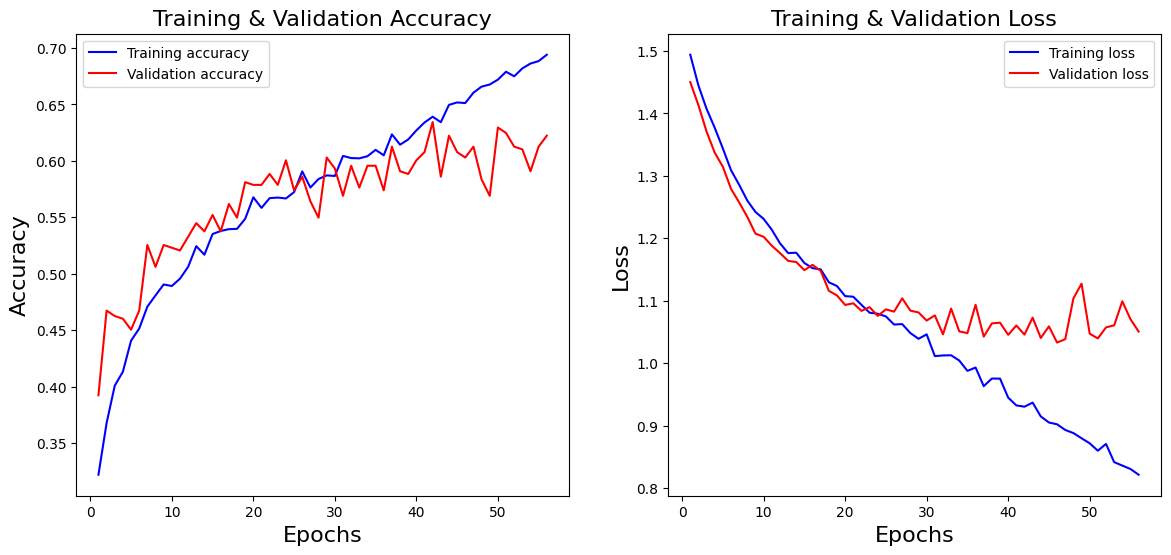

In [14]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

num_clases = len(le.classes_)

from tensorflow.keras.regularizers import l2
from sklearn.metrics import f1_score, classification_report

model = Sequential()
model.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[2])))
model.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_clases, activation='softmax'))

model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

y_pred = model.predict(X_test)
y_pred_clases = np.argmax(y_pred, axis=1)

print(f"F1 Macro:    {f1_score(y_test, y_pred_clases, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_clases, average='weighted'):.4f}")
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))

history_dict    = history.history
loss_values     = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals   = history_dict['accuracy']
val_accuracy    = history_dict['val_accuracy']
epochs          = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(epochs, accuracy_vals, 'b',   label='Training accuracy')
ax[0].plot(epochs, val_accuracy,  'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()

ax[1].plot(epochs, loss_values,     'b',   label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

plt.show()

## Probamos con embbedings contextuales -> Bert -> Pooling: max

In [15]:
# cargamos los embeddings generados previamente
X_train = np.load("../data/processed/Bert/max/X_train_bert_max.npy")
X_test  = np.load("../data/processed/Bert/max/X_test_bert_max.npy")

# cargamos las etiquetas con el mismo split que usamos al generar los embeddings
df = pd.read_csv('../data/raw/tcga_simple_train.csv')
_, _, y_train, y_test = train_test_split(df['text'], df['t'], test_size=0.2, random_state=42)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Clases:", le.classes_)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Clases: ['T1' 'T2' 'T3' 'T4']
X_train: (4126, 768), X_test: (1032, 768)
y_train: (4126,), y_test: (1032,)


c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 1, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 1, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,196 (1.16 MB)

 Trainable params: 304,196 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3140 - loss: 1.5115 - val_accuracy: 0.3269 - val_loss: 1.4669
Epoch 2/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3121 - loss: 1.4728 - val_accuracy: 0.3632 - val_loss: 1.4389
Epoch 3/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3399 - loss: 1.4512 - val_accuracy: 0.3584 - val_loss: 1.4348
Epoch 4/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3464 - loss: 1.4398 - val_accuracy: 0.3269 - val_loss: 1.4241
Epoch 5/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3372 - loss: 1.4320 - val_accuracy: 0.3269 - val_loss: 1.4219
Epoch 6/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3455 - loss: 1.4238 - val_accuracy: 0.3971 - val_loss: 1.4068
Epoch 7/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3544 - loss: 1.4168 - val_accuracy: 0.4019 - val_loss: 1.3950
Epoch 8/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3612 - loss: 1.4049 - val_accu

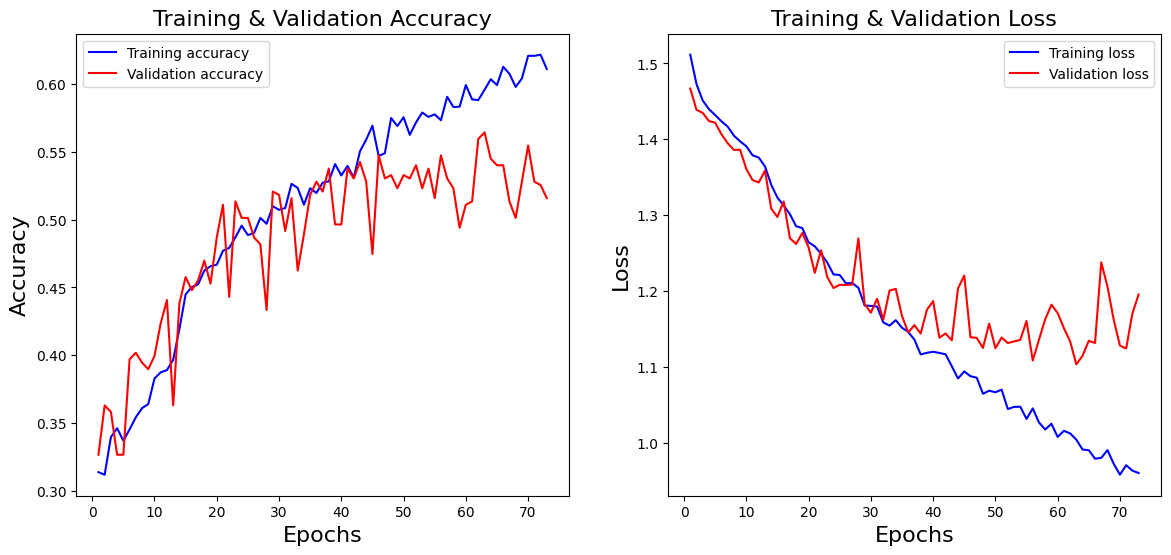

In [16]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

num_clases = len(le.classes_)

from tensorflow.keras.regularizers import l2
from sklearn.metrics import f1_score, classification_report

model = Sequential()
model.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[2])))
model.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_clases, activation='softmax'))

model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

y_pred = model.predict(X_test)
y_pred_clases = np.argmax(y_pred, axis=1)

print(f"F1 Macro:    {f1_score(y_test, y_pred_clases, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_clases, average='weighted'):.4f}")
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))

history_dict    = history.history
loss_values     = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals   = history_dict['accuracy']
val_accuracy    = history_dict['val_accuracy']
epochs          = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(epochs, accuracy_vals, 'b',   label='Training accuracy')
ax[0].plot(epochs, val_accuracy,  'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()

ax[1].plot(epochs, loss_values,     'b',   label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

plt.show()

# Los mejores resultados hasta ahora los hemos conseguido con **BERT**

# Vamos a crear un nuevo `X_train` formado por Bert con max y Bert con mean

In [23]:
X_train_mean = np.load("../data/processed/Bert/mean/X_train_bert_mean.npy")
X_test_mean  = np.load("../data/processed/Bert/mean/X_test_bert_mean.npy")

X_train_max  = np.load("../data/processed/Bert/max/X_train_bert_max.npy")
X_test_max   = np.load("../data/processed/Bert/max/X_test_bert_max.npy")

# concatenamos mean y max -> (n_muestras, 1536)
X_train = np.concatenate([X_train_mean, X_train_max], axis=1)
X_test  = np.concatenate([X_test_mean,  X_test_max],  axis=1)

print(f"Shape X_train concatenado: {X_train.shape}")
print(f"Shape X_test concatenado:  {X_test.shape}")

Shape X_train concatenado: (4126, 1536)
Shape X_test concatenado:  (1032, 1536)


c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 1, 256)         │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 1, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_6          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,804 (1.91 MB)

 Trainable params: 500,804 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2828 - loss: 1.9102 - val_accuracy: 0.3269 - val_loss: 1.7880 - learning_rate: 5.0000e-05
Epoch 2/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3062 - loss: 1.7910 - val_accuracy: 0.3269 - val_loss: 1.7752 - learning_rate: 5.0000e-05
Epoch 3/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3006 - loss: 1.7746 - val_accuracy: 0.3269 - val_loss: 1.7605 - learning_rate: 5.0000e-05
Epoch 4/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3159 - loss: 1.7536 - val_accuracy: 0.3269 - val_loss: 1.7521 - learning_rate: 5.0000e-05
Epoch 5/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3100 - loss: 1.7516 - val_accuracy: 0.3269 - val_loss: 1.7528 - learning_rate: 5.0000e-05
Epoch 6/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3130 - loss: 1.7445 - val_accuracy: 0.3269 - val_loss: 1.7402 - learning_rate: 5.0000e-05
Epoch 7/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc

c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


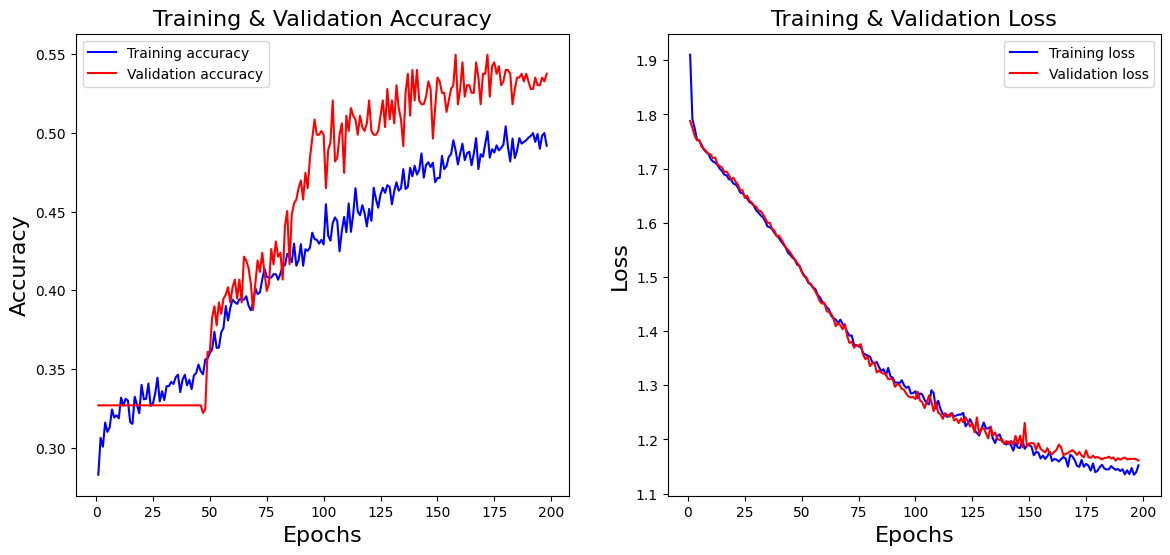

In [22]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

num_clases = len(le.classes_)

model = Sequential()
model.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[2])))
model.add(Dropout(0.4))
model.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
model.add(Dropout(0.4))
model.add(GlobalMaxPooling1D())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(num_clases, activation='softmax'))

model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# reducimos lr automaticamente si el val_loss se estanca
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=0.000001, verbose=1
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

y_pred = model.predict(X_test)
y_pred_clases = np.argmax(y_pred, axis=1)

print(f"F1 Macro:    {f1_score(y_test, y_pred_clases, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_clases, average='weighted'):.4f}")
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))

history_dict    = history.history
loss_values     = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals   = history_dict['accuracy']
val_accuracy    = history_dict['val_accuracy']
epochs          = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(epochs, accuracy_vals, 'b',   label='Training accuracy')
ax[0].plot(epochs, val_accuracy,  'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()

ax[1].plot(epochs, loss_values,     'b',   label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

plt.show()

# Probamos sin pooling, primero con BERT

In [24]:
X_train = np.load("../data/processed/Bert/X_train_bert_tokens.npy")
X_test  = np.load("../data/processed/Bert/X_test_bert_tokens.npy")

c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 48, 128)        │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_13         │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,556 (1.16 MB)

 Trainable params: 303,556 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
115/117 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2769 - loss: 2.1090 — val_f1_macro: 0.2520 — val_f1_weighted: 0.3011
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2847 - loss: 1.8493 - val_accuracy: 0.3196 - val_loss: 1.3258 - val_f1_macro: 0.2520 - val_f1_weighted: 0.3011 - learning_rate: 5.0000e-05
Epoch 2/200
111/117 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3069 - loss: 1.5116 — val_f1_macro: 0.2917 — val_f1_weighted: 0.3488
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3073 - loss: 1.4814 - val_accuracy: 0.3680 - val_loss: 1.3212 - val_f1_macro: 0.2917 - val_f1_weighted: 0.3488 - learning_rate: 5.0000e-05
Epoch 3/200
113/117 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3135 - loss: 1.4266 — val_f1_macro: 0.2920 — val_f1_weighted: 0.3532
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3135 - loss: 1.4098 - val_accuracy: 0.3729 - val_loss: 1.3116 - val_f1_macro: 0.2920 - val_f1_weighted: 0.3532 - learning_rate: 5.0000e-05
Epoch 4/20

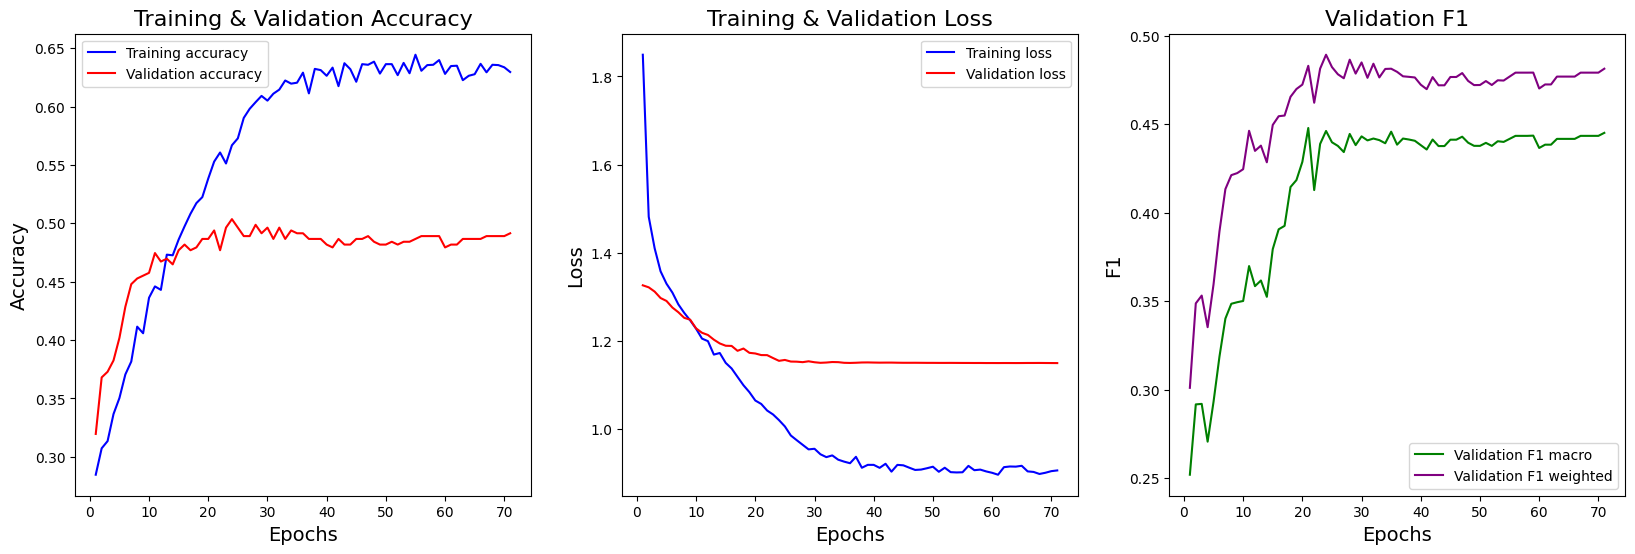

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dropout, GlobalMaxPooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, classification_report


num_clases = len(le.classes_)

# -------------------------------------------------------------------
# separamos manualmente una parte de train para validación
# así luego podemos calcular F1 sobre validación en cada época
# -------------------------------------------------------------------
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

# -------------------------------------------------------------------
# callback para calcular F1 macro y F1 weighted en validación
# -------------------------------------------------------------------
class F1Callback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.val_f1_macro = []
        self.val_f1_weighted = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        y_pred_probs = self.model.predict(self.X_val, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)

        f1_macro = f1_score(self.y_val, y_pred, average='macro')
        f1_weighted = f1_score(self.y_val, y_pred, average='weighted')

        self.val_f1_macro.append(f1_macro)
        self.val_f1_weighted.append(f1_weighted)

        logs['val_f1_macro'] = f1_macro
        logs['val_f1_weighted'] = f1_weighted

        print(f" — val_f1_macro: {f1_macro:.4f} — val_f1_weighted: {f1_weighted:.4f}")


# -------------------------------------------------------------------
# modelo
# -------------------------------------------------------------------
model = Sequential()
model.add(Conv1D(
    filters=128,
    kernel_size=3,
    activation='relu',
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(GlobalMaxPooling1D())
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(num_clases, activation='softmax'))

model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------------------------------------------
# callbacks
# -------------------------------------------------------------------
f1_callback = F1Callback(validation_data=(X_val, y_val))

# ahora reducimos lr si se estanca el F1 macro de validación
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_f1_macro',
    mode='max',
    factor=0.5,
    patience=4,
    min_lr=0.000001,
    verbose=1
)

# y también paramos usando F1 macro
early_stop = EarlyStopping(
    monitor='val_f1_macro',
    mode='max',
    patience=50,
    restore_best_weights=True,
    verbose=1
)

# -------------------------------------------------------------------
# entrenamiento
# -------------------------------------------------------------------
history = model.fit(
    X_train_sub,
    y_train_sub,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[f1_callback, reduce_lr, early_stop],
    verbose=1
)

# -------------------------------------------------------------------
# evaluación final en test
# -------------------------------------------------------------------
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

y_pred = model.predict(X_test, verbose=0)
y_pred_clases = np.argmax(y_pred, axis=1)

f1_macro_test = f1_score(y_test, y_pred_clases, average='macro')
f1_weighted_test = f1_score(y_test, y_pred_clases, average='weighted')

print(f"F1 Macro:    {f1_macro_test:.4f}")
print(f"F1 Weighted: {f1_weighted_test:.4f}")
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))

# -------------------------------------------------------------------
# gráficas
# -------------------------------------------------------------------
history_dict = history.history

loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

val_f1_macro = f1_callback.val_f1_macro
val_f1_weighted = f1_callback.val_f1_weighted

epochs = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].plot(epochs, accuracy_vals, 'b', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=14)
ax[0].set_ylabel('Accuracy', fontsize=14)
ax[0].legend()

ax[1].plot(epochs, loss_values, 'b', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=14)
ax[1].set_ylabel('Loss', fontsize=14)
ax[1].legend()

ax[2].plot(epochs, val_f1_macro, 'green', label='Validation F1 macro')
ax[2].plot(epochs, val_f1_weighted, 'purple', label='Validation F1 weighted')
ax[2].set_title('Validation F1', fontsize=16)
ax[2].set_xlabel('Epochs', fontsize=14)
ax[2].set_ylabel('F1', fontsize=14)
ax[2].legend()

plt.show()